# Aufgabe 6 (Analyse von Stromtarif-Angeboten für Endkunden)

**In dieser Aufgabe sollen Neukunden-Angebotspreise für Endkunden in verschiedenen bayerischen Städten aus dem Jahr 2024 analysiert werden, wie sie beispielsweise auf Preisvergleichsportalen zu finden sind. Es ist pro Tag und Stadt eine JSON-Datei gegeben, in der bis zu 20 Tarifangebote aufgeführt sind, die an diesem Tag in dieser Stadt am günstigsten waren (Sortierung nach `Preis im 1. Jahr`) Die angebotenen Tarife beziehen sich jeweils auf einen jährlichen Gesamtverbrauch von 4000 kWh/Jahr. \
 a) Führen Sie die gegebenen Preisvergleichdaten in einem DataFrame namens `df_cust` zusammen. Exportieren Sie diesen als CSV-Datei namens `prices_customers.csv` und
 laden Sie diese mit Ihrer Abgabe auf Moodle hoch. Verwerfen Sie bitte zur Minimierung der Dateigröße alle Spalten, die im weiteren Verlauf nicht mehr verwendet werden. Kommentieren Sie nun den Code zur Datensatzgenerierung aus und lesen Sie die CSV-Datei in den DataFrame `df_cust` erneut aus dieser Datei ein. \
 b) Bereiten Sie die Daten auf die weitere Analyse vor, indem Sie geeignete Datentransformations- und-bereinigungsschritte durchführen.**

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openmeteo_requests
import requests_cache
from retry_requests import retry
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor
import glob

In [24]:
'''import os
import glob
import pandas as pd
from datetime import datetime
import json
def process_json_files(input_dir, output_file):
    all_data = []  # List to collect all rows
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.endswith('.json'):
                file_path = os.path.join(root, file)
                with open(file_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    # Extracting date from folder name
                    date = os.path.basename(root)
                    if not date:  # If no date folder, use filename
                        date = file.split('_')[0]
                    # Convert to datetime
                    
                    # Append rows to the list
                    for item in data.values():
                        item['Date'] = date
                        all_data.append(item)
    
    # Convert to DataFrame
    df = pd.DataFrame(all_data)
    
    # Data cleaning and formatting
    
    
    # Save to CSV
    df.to_csv(output_file, index=False, encoding='utf-8')
    print(f"Data successfully saved to {output_file}")

# Example usage
input_directory = "DAT-WS2425-Projektarbeit/DAT-WS2425-Projektarbeit/Daten/Endkundenpreise"  # Replace with the directory path
output_csv = "prices_customers.csv"
process_json_files(input_directory, output_csv)

# Display the resulting DataFrame'''

'import os\nimport glob\nimport pandas as pd\nfrom datetime import datetime\nimport json\ndef process_json_files(input_dir, output_file):\n    all_data = []  # List to collect all rows\n    for root, dirs, files in os.walk(input_dir):\n        for file in files:\n            if file.endswith(\'.json\'):\n                file_path = os.path.join(root, file)\n                with open(file_path, \'r\', encoding=\'utf-8\') as f:\n                    data = json.load(f)\n                    # Extracting date from folder name\n                    date = os.path.basename(root)\n                    if not date:  # If no date folder, use filename\n                        date = file.split(\'_\')[0]\n                    # Convert to datetime\n                    \n                    # Append rows to the list\n                    for item in data.values():\n                        item[\'Date\'] = date\n                        all_data.append(item)\n    \n    # Convert to DataFrame\n    df = pd

In [25]:
df_cust = pd.read_csv('prices_customers.csv', low_memory=False)
df_cust

,Postleitzahl,Jahresverbrauch,Abschlagszahlung,Grundpreis,Arbeitspreis,Preisgarantie,Vertragslaufzeit,Verlängerung,Kündigungsfrist,Preis im 1. Jahr*,...,Grundpreisrabatt:,Neukundenbonus,Sofortbonus,Preis im 1. Jahr,Arbeitspreisrabatt,Zusätzlicher Aktionsbonus,Blitzbonus,Abschlagsrabatt,Grundpreisrabatt,Winterprämie
0,80331.0,4.000 kWh,monatlich,"14,40 €/Monat (172,86 €/Jahr)","19,61 Cent/kWh",1 Monat Preisfixierung,1 Monat,1 Monat,1 Monat,"79,77 €/Monat",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,80331.0,4.000 kWh,monatlich,"11,16 €/Monat (133,88 €/Jahr)","22,02 Cent/kWh",1 Monat Nettopreisgarantie,1 Monat,1 Monat,1 Monat,"81,57 €/Monat",...,3 €/Monat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,80331.0,4.000 kWh,monatlich,"13,14 €/Monat (157,62 €/Jahr)","28,59 Cent/kWh",12 Monate Nettopreisgarantie,12 Monate,1 Monat,1 Monat,NaN,...,NaN,189 € einmalig,111 € einmalig,"83,44 €/Monat",NaN,NaN,NaN,NaN,NaN,NaN
3,80331.0,4.000 kWh,monatlich,"11,16 €/Monat (133,88 €/Jahr)","21,99 Cent/kWh",1 Monat Nettopreisgarantie,1 Monat,2 Wochen,2 Wochen,"84,46 €/Monat",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,80331.0,4.000 kWh,monatlich,"22,51 €/Monat (270,17 €/Jahr)","27,01 Cent/kWh",12 Monate Preisfixierung,12 Monate,1 Monat,1 Monat,NaN,...,NaN,15 % auf Rechnungsbetrag (202 € ),50 € einmalig,"91,51 €/Monat",NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256335,97070.0,4.000 kWh,monatlich,"17,50 €/Monat (210,00 €/Jahr)","27,67 Cent/kWh",12 Monate Preisfixierung,12 Monate,1 Monat,1 Monat zum Monatsende,NaN,...,NaN,15 % auf Rechnungsbetrag,72 €,"87,31 €/Monat",NaN,NaN,NaN,NaN,NaN,NaN
256336,97070.0,4.000 kWh,monatlich,"15,90 €/Monat (190,80 €/Jahr)","26,18 Cent/kWh",Preisfixierung bis 30.06.2026,12 Monate,1 Monat,1 Monat,NaN,...,NaN,170 €,20 €,"87,33 €/Monat",NaN,NaN,NaN,NaN,NaN,NaN
256337,97070.0,4.000 kWh,monatlich,"16,05 €/Monat (192,55 €/Jahr)","24,77 Cent/kWh",12 Monate Nettopreisgarantie,12 Monate,1 Monat,1 Monat,NaN,...,NaN,135 €,NaN,"87,38 €/Monat",NaN,NaN,NaN,NaN,NaN,NaN
256338,97070.0,4.000 kWh,monatlich,"14,87 €/Monat (178,38 €/Jahr)","28,59 Cent/kWh",12 Monate Nettopreisgarantie,12 Monate,4 Wochen,4 Wochen,NaN,...,NaN,198 €,75 €,"87,42 €/Monat",NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# final_preis = (Grundpreis-GPrabatt) +(4000/12)*(AP-APR)+(PI1J-NKB)-SofortBonus-Winterprämie

In [27]:
print(df_cust.columns.tolist())

['Postleitzahl', 'Jahresverbrauch', 'Abschlagszahlung', 'Grundpreis', 'Arbeitspreis', 'Preisgarantie', 'Vertragslaufzeit', 'Verlängerung', 'Kündigungsfrist', 'Preis im 1. Jahr*', 'Stadt', 'Anbieter', 'Tarif', 'Date', 'Grundpreisrabatt:', 'Neukundenbonus', 'Sofortbonus', 'Preis im 1. Jahr', 'Arbeitspreisrabatt', 'Zusätzlicher Aktionsbonus', 'Blitzbonus', 'Abschlagsrabatt', 'Grundpreisrabatt', 'Winterprämie']


In [28]:
df_cust['Jahresverbrauch'] = pd.to_numeric(df_cust['Jahresverbrauch'].str.extract(r'(\d+\.\d+)')[0].str.replace('.', ''), errors='coerce')
df_cust['Grundpreis'] = pd.to_numeric(df_cust['Grundpreis'].str.extract(r'(\d+\,\d+)')[0].str.replace(',', '.'), errors='coerce')
df_cust['Arbeitspreis'] = pd.to_numeric(df_cust['Arbeitspreis'].str.extract(r'(\d+\,\d+)')[0].str.replace(',', '.'), errors='coerce')
df_cust['Preis im 1. Jahr*'] = pd.to_numeric(df_cust['Preis im 1. Jahr*'].str.extract(r'(\d+\,\d+)')[0].str.replace(',', '.'), errors='coerce')
df_cust['Preis im 1. Jahr'] = pd.to_numeric(df_cust['Preis im 1. Jahr'].str.extract(r'(\d+\,\d+)')[0].str.replace(',', '.'), errors='coerce')
df_cust['Vertragslaufzeit'] = pd.to_numeric(df_cust['Vertragslaufzeit'].str.extract(r'(\d+)')[0], errors='coerce')
#final_df['Preisgarantie'] = pd.to_numeric(final_df['Preisgarantie'].str.extract(r'(\d+)')[0], errors='coerce')
#final_df['Verlängerung'] = pd.to_numeric(final_df['Verlängerung'].str.extract(r'(\d+)')[0], errors='coerce')
#final_df['Kündigungsfrist'] = pd.to_numeric(final_df['Kündigungsfrist'].str.extract(r'(\d+)')[0], errors='coerce')
df_cust

,Postleitzahl,Jahresverbrauch,Abschlagszahlung,Grundpreis,Arbeitspreis,Preisgarantie,Vertragslaufzeit,Verlängerung,Kündigungsfrist,Preis im 1. Jahr*,...,Grundpreisrabatt:,Neukundenbonus,Sofortbonus,Preis im 1. Jahr,Arbeitspreisrabatt,Zusätzlicher Aktionsbonus,Blitzbonus,Abschlagsrabatt,Grundpreisrabatt,Winterprämie
0,80331.0,4000.0,monatlich,14.40,19.61,1 Monat Preisfixierung,1.0,1 Monat,1 Monat,79.77,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,80331.0,4000.0,monatlich,11.16,22.02,1 Monat Nettopreisgarantie,1.0,1 Monat,1 Monat,81.57,...,3 €/Monat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,80331.0,4000.0,monatlich,13.14,28.59,12 Monate Nettopreisgarantie,12.0,1 Monat,1 Monat,NaN,...,NaN,189 € einmalig,111 € einmalig,83.44,NaN,NaN,NaN,NaN,NaN,NaN
3,80331.0,4000.0,monatlich,11.16,21.99,1 Monat Nettopreisgarantie,1.0,2 Wochen,2 Wochen,84.46,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,80331.0,4000.0,monatlich,22.51,27.01,12 Monate Preisfixierung,12.0,1 Monat,1 Monat,NaN,...,NaN,15 % auf Rechnungsbetrag (202 € ),50 € einmalig,91.51,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256335,97070.0,4000.0,monatlich,17.50,27.67,12 Monate Preisfixierung,12.0,1 Monat,1 Monat zum Monatsende,NaN,...,NaN,15 % auf Rechnungsbetrag,72 €,87.31,NaN,NaN,NaN,NaN,NaN,NaN
256336,97070.0,4000.0,monatlich,15.90,26.18,Preisfixierung bis 30.06.2026,12.0,1 Monat,1 Monat,NaN,...,NaN,170 €,20 €,87.33,NaN,NaN,NaN,NaN,NaN,NaN
256337,97070.0,4000.0,monatlich,16.05,24.77,12 Monate Nettopreisgarantie,12.0,1 Monat,1 Monat,NaN,...,NaN,135 €,NaN,87.38,NaN,NaN,NaN,NaN,NaN,NaN
256338,97070.0,4000.0,monatlich,14.87,28.59,12 Monate Nettopreisgarantie,12.0,4 Wochen,4 Wochen,NaN,...,NaN,198 €,75 €,87.42,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
df_cust['Preis im 1. Jahr'] = df_cust['Preis im 1. Jahr'].fillna(df_cust['Preis im 1. Jahr*'])
df_cust = df_cust.drop(columns=['Preis im 1. Jahr*'])
df_cust

,Postleitzahl,Jahresverbrauch,Abschlagszahlung,Grundpreis,Arbeitspreis,Preisgarantie,Vertragslaufzeit,Verlängerung,Kündigungsfrist,Stadt,...,Grundpreisrabatt:,Neukundenbonus,Sofortbonus,Preis im 1. Jahr,Arbeitspreisrabatt,Zusätzlicher Aktionsbonus,Blitzbonus,Abschlagsrabatt,Grundpreisrabatt,Winterprämie
0,80331.0,4000.0,monatlich,14.40,19.61,1 Monat Preisfixierung,1.0,1 Monat,1 Monat,München,...,NaN,NaN,NaN,79.77,NaN,NaN,NaN,NaN,NaN,NaN
1,80331.0,4000.0,monatlich,11.16,22.02,1 Monat Nettopreisgarantie,1.0,1 Monat,1 Monat,München,...,3 €/Monat,NaN,NaN,81.57,NaN,NaN,NaN,NaN,NaN,NaN
2,80331.0,4000.0,monatlich,13.14,28.59,12 Monate Nettopreisgarantie,12.0,1 Monat,1 Monat,München,...,NaN,189 € einmalig,111 € einmalig,83.44,NaN,NaN,NaN,NaN,NaN,NaN
3,80331.0,4000.0,monatlich,11.16,21.99,1 Monat Nettopreisgarantie,1.0,2 Wochen,2 Wochen,München,...,NaN,NaN,NaN,84.46,NaN,NaN,NaN,NaN,NaN,NaN
4,80331.0,4000.0,monatlich,22.51,27.01,12 Monate Preisfixierung,12.0,1 Monat,1 Monat,München,...,NaN,15 % auf Rechnungsbetrag (202 € ),50 € einmalig,91.51,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256335,97070.0,4000.0,monatlich,17.50,27.67,12 Monate Preisfixierung,12.0,1 Monat,1 Monat zum Monatsende,Würzburg,...,NaN,15 % auf Rechnungsbetrag,72 €,87.31,NaN,NaN,NaN,NaN,NaN,NaN
256336,97070.0,4000.0,monatlich,15.90,26.18,Preisfixierung bis 30.06.2026,12.0,1 Monat,1 Monat,Würzburg,...,NaN,170 €,20 €,87.33,NaN,NaN,NaN,NaN,NaN,NaN
256337,97070.0,4000.0,monatlich,16.05,24.77,12 Monate Nettopreisgarantie,12.0,1 Monat,1 Monat,Würzburg,...,NaN,135 €,NaN,87.38,NaN,NaN,NaN,NaN,NaN,NaN
256338,97070.0,4000.0,monatlich,14.87,28.59,12 Monate Nettopreisgarantie,12.0,4 Wochen,4 Wochen,Würzburg,...,NaN,198 €,75 €,87.42,NaN,NaN,NaN,NaN,NaN,NaN


**c) Wie viele verschiedene Tarife wurden insgesamt angeboten?**

In [30]:
print(len(df_cust['Tarif'].unique()))

112


**Zu wie vielen Tagen sind pro Stadt Daten vorhanden?**

In [31]:
df_cust.groupby('Stadt').count()/20

,Postleitzahl,Jahresverbrauch,Abschlagszahlung,Grundpreis,Arbeitspreis,Preisgarantie,Vertragslaufzeit,Verlängerung,Kündigungsfrist,Anbieter,...,Grundpreisrabatt:,Neukundenbonus,Sofortbonus,Preis im 1. Jahr,Arbeitspreisrabatt,Zusätzlicher Aktionsbonus,Blitzbonus,Abschlagsrabatt,Grundpreisrabatt,Winterprämie
Stadt,,,,,,,,,,,,,,,,,,,,,
Amberg,321.95,321.95,321.95,321.95,321.95,321.95,321.95,321.95,321.95,323.0,...,2.45,234.60,206.65,321.95,26.05,1.50,11.45,2.80,9.50,0.90
Ansbach,319.05,319.05,319.05,319.05,319.05,319.05,319.05,319.05,319.05,320.0,...,2.25,228.40,192.95,319.05,26.90,0.90,12.80,2.15,8.70,1.10
Aschaffenburg,319.65,319.65,319.65,319.65,319.65,319.65,319.65,319.65,319.65,320.0,...,0.90,238.60,203.55,319.65,26.40,0.75,12.65,2.00,4.50,1.45
Augsburg,320.55,320.55,320.55,320.55,320.55,320.55,320.55,320.55,320.55,321.0,...,1.65,233.45,208.40,320.55,24.90,0.70,11.15,1.85,9.50,1.30
Bamberg,319.15,319.15,319.15,319.15,319.15,319.15,319.15,319.15,319.15,320.0,...,2.25,228.30,198.15,319.15,22.90,0.30,12.25,2.05,4.60,1.30
Bayreuth,318.75,318.75,318.75,318.75,318.75,318.75,318.75,318.75,318.75,320.0,...,2.90,229.25,201.85,318.75,30.00,0.60,11.55,1.85,10.55,0.85
Beilngries,320.60,320.60,320.60,320.60,320.60,320.60,320.60,320.60,320.60,321.0,...,2.50,230.75,199.85,320.60,19.55,0.70,10.55,2.95,5.95,1.85
Burglengenfeld,320.35,320.35,320.35,320.35,320.35,320.35,320.35,320.35,320.35,321.0,...,3.10,234.10,204.10,320.35,20.05,0.65,9.45,2.75,6.20,1.75
Cham,317.70,317.70,317.70,317.70,317.70,317.70,317.70,317.70,317.70,318.0,...,3.10,222.45,192.10,317.70,30.05,0.65,14.40,6.65,0.85,2.40


**Wie viele verschiedene Anbieter haben insgesamt Tarife angeboten?**

In [32]:
print(len(df_cust['Anbieter'].unique()))

78


In [33]:
df_cust['Tarif'] = df_cust['Tarif'].str.extract(r'Tarif\s+(.*)')
df_cust['Tarif']

0                           Fairpower one
1                         rabot.home flex
2                     ÖkoStrom Komfort 12
3                       Dynamischer Tarif
4               ELEKTRIZITÄT BERLIN Strom
                       ...               
256335               Grün & Günstig Strom
256336             LEW Strom Garant Natur
256337                         KlickStrom
256338                ENTEGA Ökostrom eco
256339    R(H)EINPOWER MeinStrom 12 Natur
Name: Tarif, Length: 256340, dtype: object

**d)  Ermitteln Sie, welche unterschiedlichen Tarife in Amberg angeboten wurden**

In [34]:
amberg_tarif=pd.Series(df_cust[df_cust['Stadt']=='Amberg']['Tarif'].unique(), name='Tarif')
amberg_tarif

0                   Fairpower one
1               Dynamischer Tarif
2             ÖkoStrom Komfort 12
3                 rabot.home flex
4       ELEKTRIZITÄT BERLIN Strom
                 ...             
72            Spar Smart FairPlus
73    extraenergie Strom 12 Bonus
74                MONTANA dynamic
75           N-ERGIE Ökostrom eco
76         LEW Strom Garant Natur
Name: Tarif, Length: 77, dtype: object

In [35]:
df_cust['Date'] = '2024-'+df_cust['Date']


In [36]:
df_cust['Date'] = pd.to_datetime(df_cust['Date'])

In [37]:
df_cust

,Postleitzahl,Jahresverbrauch,Abschlagszahlung,Grundpreis,Arbeitspreis,Preisgarantie,Vertragslaufzeit,Verlängerung,Kündigungsfrist,Stadt,...,Grundpreisrabatt:,Neukundenbonus,Sofortbonus,Preis im 1. Jahr,Arbeitspreisrabatt,Zusätzlicher Aktionsbonus,Blitzbonus,Abschlagsrabatt,Grundpreisrabatt,Winterprämie
0,80331.0,4000.0,monatlich,14.40,19.61,1 Monat Preisfixierung,1.0,1 Monat,1 Monat,München,...,NaN,NaN,NaN,79.77,NaN,NaN,NaN,NaN,NaN,NaN
1,80331.0,4000.0,monatlich,11.16,22.02,1 Monat Nettopreisgarantie,1.0,1 Monat,1 Monat,München,...,3 €/Monat,NaN,NaN,81.57,NaN,NaN,NaN,NaN,NaN,NaN
2,80331.0,4000.0,monatlich,13.14,28.59,12 Monate Nettopreisgarantie,12.0,1 Monat,1 Monat,München,...,NaN,189 € einmalig,111 € einmalig,83.44,NaN,NaN,NaN,NaN,NaN,NaN
3,80331.0,4000.0,monatlich,11.16,21.99,1 Monat Nettopreisgarantie,1.0,2 Wochen,2 Wochen,München,...,NaN,NaN,NaN,84.46,NaN,NaN,NaN,NaN,NaN,NaN
4,80331.0,4000.0,monatlich,22.51,27.01,12 Monate Preisfixierung,12.0,1 Monat,1 Monat,München,...,NaN,15 % auf Rechnungsbetrag (202 € ),50 € einmalig,91.51,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256335,97070.0,4000.0,monatlich,17.50,27.67,12 Monate Preisfixierung,12.0,1 Monat,1 Monat zum Monatsende,Würzburg,...,NaN,15 % auf Rechnungsbetrag,72 €,87.31,NaN,NaN,NaN,NaN,NaN,NaN
256336,97070.0,4000.0,monatlich,15.90,26.18,Preisfixierung bis 30.06.2026,12.0,1 Monat,1 Monat,Würzburg,...,NaN,170 €,20 €,87.33,NaN,NaN,NaN,NaN,NaN,NaN
256337,97070.0,4000.0,monatlich,16.05,24.77,12 Monate Nettopreisgarantie,12.0,1 Monat,1 Monat,Würzburg,...,NaN,135 €,NaN,87.38,NaN,NaN,NaN,NaN,NaN,NaN
256338,97070.0,4000.0,monatlich,14.87,28.59,12 Monate Nettopreisgarantie,12.0,4 Wochen,4 Wochen,Würzburg,...,NaN,198 €,75 €,87.42,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
import plotly.graph_objects as go
df_cust_amberg = df_cust[df_cust['Stadt']=='Amberg'][['Tarif', 'Date']].value_counts().reset_index()
fig = go.Figure(data=go.Heatmap(z=df_cust_amberg['count'], x=df_cust_amberg['Tarif'], y= df_cust_amberg['Date'], colorscale='Viridis', zmin=0, zmax=2))
fig.update_layout(width=1000, height = 1000)
fig.show()
df_cust_amberg

C:\Users\thomm\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



,Tarif,Date,count
0,LEW Strom Fix Natur,2024-07-13,2
1,LEW Strom Fix Natur,2024-07-14,2
2,LEW Strom Fix Natur,2024-07-15,2
3,123strom,2024-01-25,1
4,Strom Bonus 12,2024-05-14,1
...,...,...,...
6452,LEW Strom Fix Natur,2024-09-01,1
6453,LEW Strom Fix Natur,2024-08-31,1
6454,LEW Strom Fix Natur,2024-08-30,1
6455,LEW Strom Fix Natur,2024-08-29,1


<Axes: xlabel='Date'>

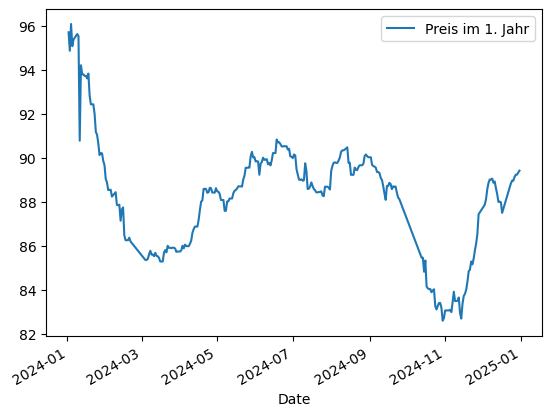

In [39]:
df_avg=df_cust.groupby(['Date'])['Preis im 1. Jahr'].mean().reset_index()
df_avg.plot(x='Date', y='Preis im 1. Jahr', kind='line')

In [49]:
import plotly.express as px
staedte = df_cust['Stadt'].unique()
fig = go.Figure()
for stadt in staedte:
    uniquedf= df_cust[df_cust['Stadt']==stadt][['Preis im 1. Jahr', 'Date']]
    uniquedf = uniquedf.groupby(['Date'])['Preis im 1. Jahr'].mean().reset_index()
    fig.add_trace(
        go.Scatter(
            x=uniquedf['Date'],
            y=uniquedf['Preis im 1. Jahr'], 
            mode='lines',
            name =stadt
        )
    )
buttons=[]
length = len(staedte)
for i, stadt in enumerate(staedte):
    visible= [False]*length
    visible[i] = True
    
    buttons.append(
        dict(
            label=stadt,
            method='update',
            args=[{'visible': visible}]
        )
    )
buttons.append(
    dict(
        label ='All',
        method='update',
        args=[{'visible':[True]*length}]
    )
)

fig.update_layout(
    updatemenus=[
        dict(
            active=0,
            buttons=buttons
        )
    ]
)
fig.show()
'''top10_tariffe_proStadt = (df_cust.groupby('Stadt')['Tarif'].value_counts().groupby(level=0).head(10).reset_index(name='count'))

df_filtered=df_cust.merge(top10_tariffe_proStadt,on=['Stadt','Tarif'])'''

    

C:\Users\thomm\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

C:\Users\thomm\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

C:\Users\thomm\anaconda3\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

C:\Users\thomm\anaconda3\Lib\si

"top10_tariffe_proStadt = (df_cust.groupby('Stadt')['Tarif'].value_counts().groupby(level=0).head(10).reset_index(name='count'))\n\ndf_filtered=df_cust.merge(top10_tariffe_proStadt,on=['Stadt','Tarif'])"